<a href="https://colab.research.google.com/github/Wallflower415/Trabalho-Spaceship-Titanic/blob/main/Trabalho_Spaceship_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Spaceship Titanic — Predição de Transporte

**Disciplina:** Inteligência Computacional  
**Curso:** Tecnologia em Ciência de Dados — Fatec Jundiaí  
**Professor:** Me. Mateus Guilherme Fuini  

---

## Descrição do Problema

O dataset **Spaceship Titanic** (Kaggle) simula um cenário de ficção científica: uma nave espacial colidiu com uma anomalia espaço-temporal e parte dos passageiros foi transportada para outra dimensão. O objetivo é **prever quais passageiros foram transportados** (`Transported = True/False`) com base em informações como origem, destino, cabine, gastos a bordo e dados demográficos.

- **Tipo de problema:** Classificação binária
- **Variável alvo:** `Transported`
- **Dataset:** [Spaceship Titanic — Kaggle](https://www.kaggle.com/competitions/spaceship-titanic/data)
- **Tamanho:** ~8.700 registros de treino, 14 colunas

---

## Índice

1. [Configuração e Carregamento dos Dados](#1)
2. [Análise Exploratória de Dados (EDA)](#2)
3. [Engenharia de Atributos](#3)
4. [Pré-processamento e Pipeline](#4)
5. [Data Leakage](#5)
6. [Modelagem](#6)
7. [Validação: K-Fold e GridSearchCV](#7)
8. [Avaliação dos Resultados](#8)
9. [Discussão Final](#9)

---
## 1. Configuração e Carregamento dos Dados <a id='1'></a>

In [3]:
# Instalação (caso necessário no Colab)
# !pip install kaggle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='darkgrid')

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


In [4]:
!pip install kaggle -q

from google.colab import files
import os, json

# Faça upload do seu kaggle.json (Settings -> API -> Create New Token)
# Lembre-se de aceitar os termos da competição em kaggle.com/competitions/spaceship-titanic
uploaded = files.upload()
filename = list(uploaded.keys())[0]
creds = json.loads(uploaded[filename].decode('utf-8'))

os.environ['KAGGLE_USERNAME'] = creds['username']
os.environ['KAGGLE_KEY'] = creds['key']

print(f'✅ Autenticado como: {creds["username"]}')

!kaggle competitions download -c spaceship-titanic
!unzip -o spaceship-titanic.zip

df = pd.read_csv('train.csv')
print(f'\nShape: {df.shape}')
df.head()

Saving kaggle.json to kaggle.json
✅ Autenticado como: juliocesar415
100% 299k/299k [00:00<00:00, 115MB/s]

Archive:  spaceship-titanic.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               

Shape: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
# Visão geral das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [6]:
# Estatísticas descritivas
df.describe(include='all')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8492,8476,8494,8511,8514.000000,8490,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000,8493,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,9280_02,Earth,False,G/734/S,TRAPPIST-1e,NaN,False,NaN,NaN,NaN,NaN,NaN,Ankalik Nateansive,True
freq,1,4602,5439,8,5915,NaN,8291,NaN,NaN,NaN,NaN,NaN,2,4378
mean,NaN,NaN,NaN,NaN,NaN,28.827930,NaN,224.687617,458.077203,173.729169,311.138778,304.854791,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.489021,NaN,666.717663,1611.489240,604.696458,1136.705535,1145.717189,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,19.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,47.000000,76.000000,27.000000,59.000000,46.000000,NaN,NaN


In [7]:
# Análise estatística detalhada das variáveis numéricas
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
num_cols = spend_cols + ['Age']

stats = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew'])
print('=== Estatísticas Descritivas — Variáveis Numéricas ===')
print(stats.round(2).to_string())

print('\n=== Percentual de Zeros nas Colunas de Gastos ===')
for col in spend_cols:
    pct_zero = (df[col] == 0).sum() / df[col].notna().sum() * 100
    print(f'  {col}: {pct_zero:.1f}% zeros')

=== Estatísticas Descritivas — Variáveis Numéricas ===
        RoomService  FoodCourt  ShoppingMall       Spa    VRDeck    Age
mean         224.69     458.08        173.73    311.14    304.85  28.83
median         0.00       0.00          0.00      0.00      0.00  27.00
std          666.72    1611.49        604.70   1136.71   1145.72  14.49
min            0.00       0.00          0.00      0.00      0.00   0.00
max        14327.00   29813.00      23492.00  22408.00  24133.00  79.00
skew           6.33       7.10         12.63      7.64      7.82   0.42

=== Percentual de Zeros nas Colunas de Gastos ===
  RoomService: 65.5% zeros
  FoodCourt: 64.1% zeros
  ShoppingMall: 65.8% zeros
  Spa: 62.6% zeros
  VRDeck: 64.6% zeros


### Interpretação das Estatísticas Descritivas

**Idade (`Age`):**
- Média próxima de 28 anos, com desvio padrão de ~14 anos — distribuição relativamente jovem.
- Valores entre 0 e 79 anos, sem idades negativas ou implausíveis.

**Gastos a bordo (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`):**
- Todas as colunas apresentam **forte assimetria positiva** (skewness alto): a maioria dos passageiros não gastou nada, mas uma minoria gastou valores muito elevados.
- A **mediana é próxima de zero** em todas, enquanto a **média é bem maior** — confirmando a presença de outliers de alto valor.
- Isso sugere que a mediana é mais adequada do que a média para imputação de valores ausentes nessas colunas.
- O alto percentual de zeros é esperado: passageiros em **CryoSleep** não podem gastar nada a bordo.

**Implicações para o modelo:**
- O escalonamento (`StandardScaler`) é essencial para neutralizar as diferenças de magnitude entre colunas.
- A criação do atributo `TotalSpend` agrega o comportamento de consumo em uma única variável mais informativa.

---
## 2. Análise Exploratória de Dados (EDA) <a id='2'></a>

Nesta seção exploramos a distribuição das variáveis, valores ausentes, outliers e relações entre atributos.

### 2.1 Valores Ausentes

              Ausentes  Percentual (%)
CryoSleep          217            2.50
ShoppingMall       208            2.39
VIP                203            2.34
HomePlanet         201            2.31
Name               200            2.30
Cabin              199            2.29
VRDeck             188            2.16
Spa                183            2.11
FoodCourt          183            2.11
Destination        182            2.09
RoomService        181            2.08
Age                179            2.06


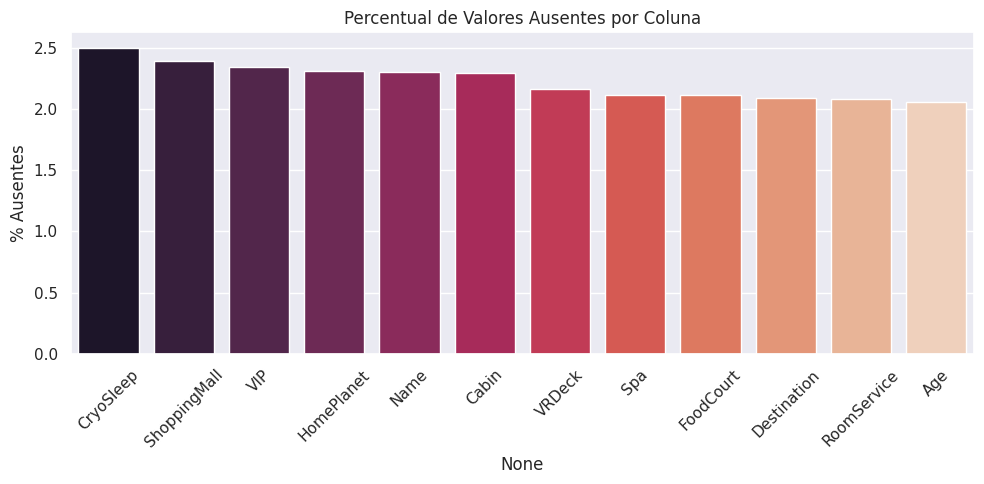

In [8]:
# Mapa de valores ausentes
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, 'Percentual (%)': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0]

print(missing_df)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Percentual (%)'], palette='rocket')
plt.title('Percentual de Valores Ausentes por Coluna')
plt.xticks(rotation=45)
plt.ylabel('% Ausentes')
plt.tight_layout()
plt.show()

### 2.2 Distribuição da Variável Alvo

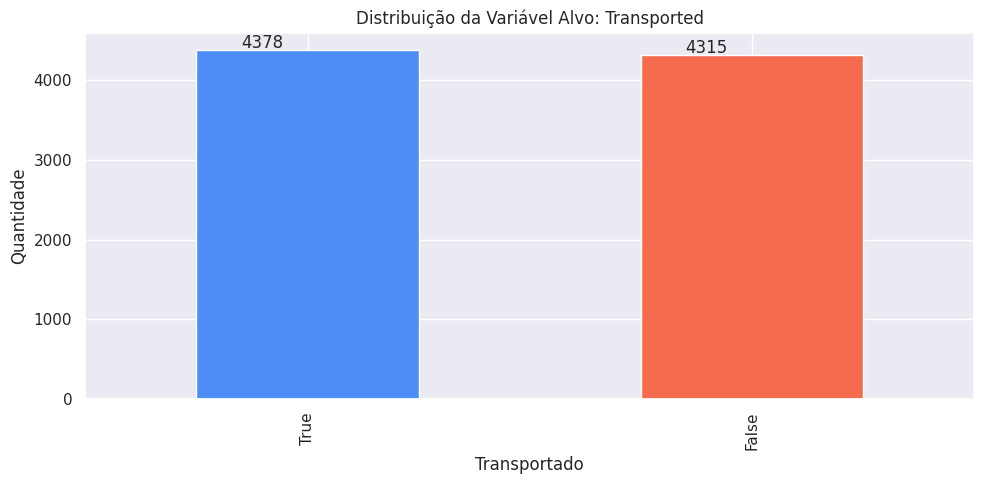

Transported
True     50.36%
False    49.64%
Name: proportion, dtype: object


In [9]:
# Distribuição do target
ax = df['Transported'].value_counts().plot(kind='bar', color=['#4e8df5', '#f56b4e'])
plt.title('Distribuição da Variável Alvo: Transported')
plt.xlabel('Transportado')
plt.ylabel('Quantidade')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.1, p.get_height() + 30))
plt.tight_layout()
plt.show()

print(df['Transported'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

### 2.3 Histogramas — Variáveis Numéricas

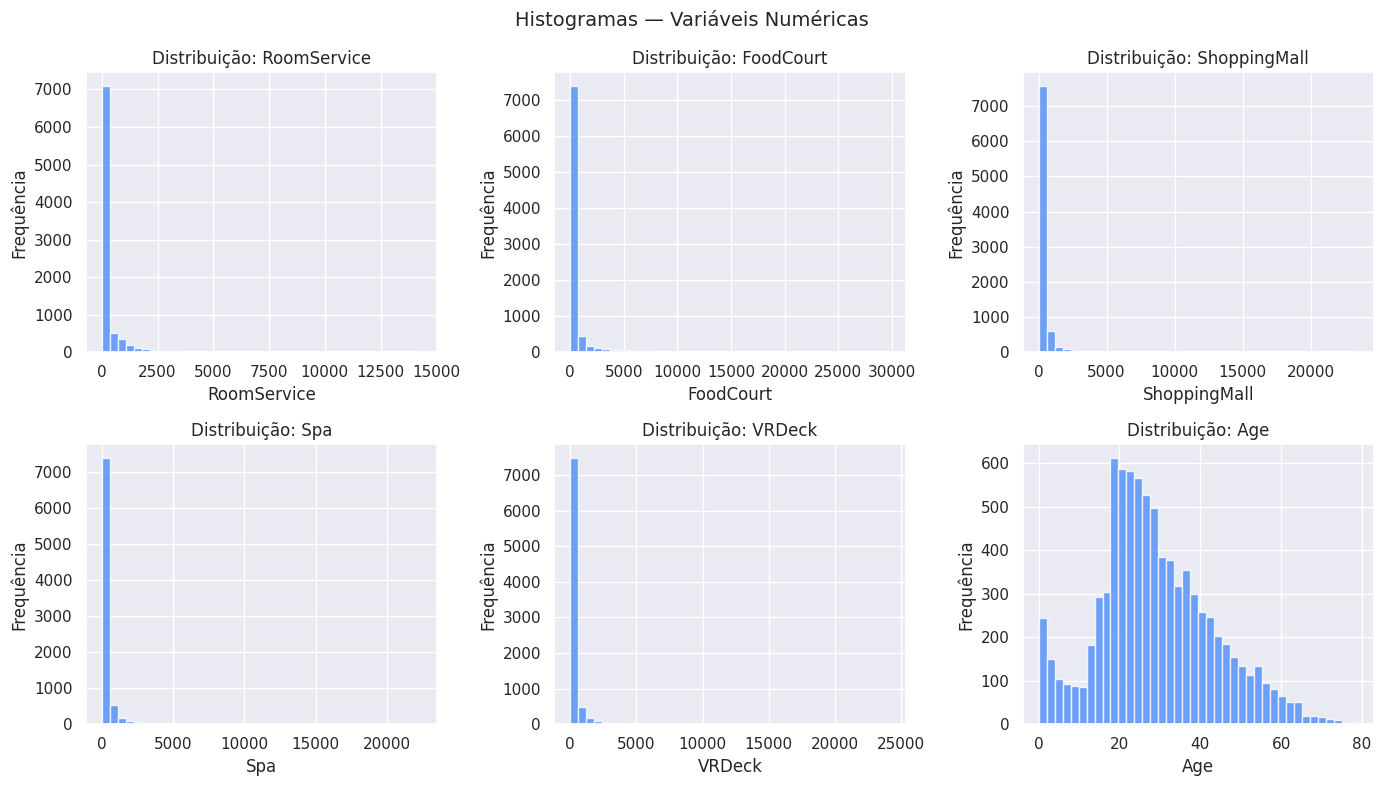

In [10]:
# Colunas de gastos a bordo
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(spend_cols + ['Age']):
    axes[i].hist(df[col].dropna(), bins=40, color='#4e8df5', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

plt.suptitle('Histogramas — Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 Boxplots — Detecção de Outliers

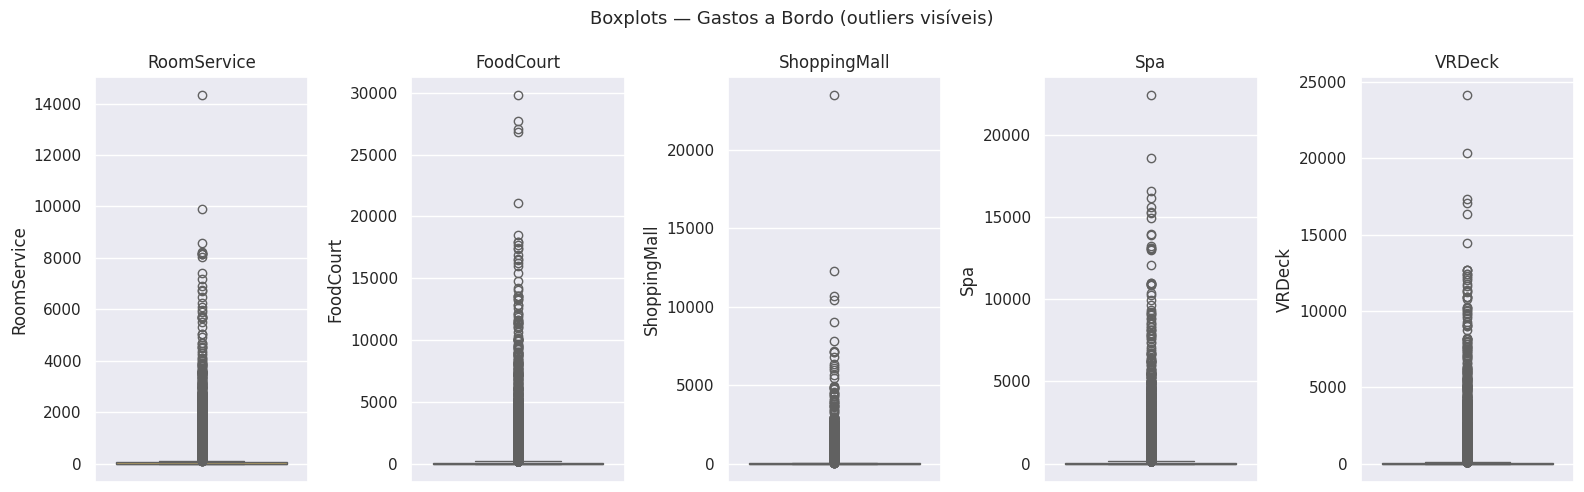

In [11]:
fig, axes = plt.subplots(1, len(spend_cols), figsize=(16, 5))

for i, col in enumerate(spend_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#f5c84e')
    axes[i].set_title(col)

plt.suptitle('Boxplots — Gastos a Bordo (outliers visíveis)', fontsize=13)
plt.tight_layout()
plt.show()

### Decisão: Manutenção dos Outliers

Os boxplots revelam a presença de outliers expressivos em todas as colunas de gastos a bordo. A decisão foi **manter esses valores** pelas seguintes razões:

**1. Outliers com significado real:**  
Os valores extremos representam passageiros que de fato gastaram muito em serviços premium da nave. Removê-los significaria descartar informação legítima e potencialmente relevante para o modelo.

**2. Relação com a variável alvo:**  
Passageiros em CryoSleep têm gastos zerados obrigatoriamente, enquanto os demais podem ter gastos altos. Essa variação extrema é um sinal preditivo importante — não um ruído.

**3. Mitigação via pré-processamento:**  
O `StandardScaler` no pipeline reduz o impacto dos outliers na escala das variáveis. Além disso, a criação do atributo `TotalSpend` agrega os gastos, suavizando o efeito de valores extremos em colunas individuais.

**4. Algoritmos utilizados:**  
O KNN é sensível à escala mas não necessariamente a outliers após a normalização. A Regressão Logística também é razoavelmente robusta a outliers em dados normalizados.

Caso fosse necessário tratar os outliers, a abordagem recomendada seria o **clipping por IQR** (limitar valores ao intervalo Q1 - 1.5×IQR / Q3 + 1.5×IQR), preservando as observações mas limitando sua influência.

### 2.5 Scatterplot — Gastos vs Transported

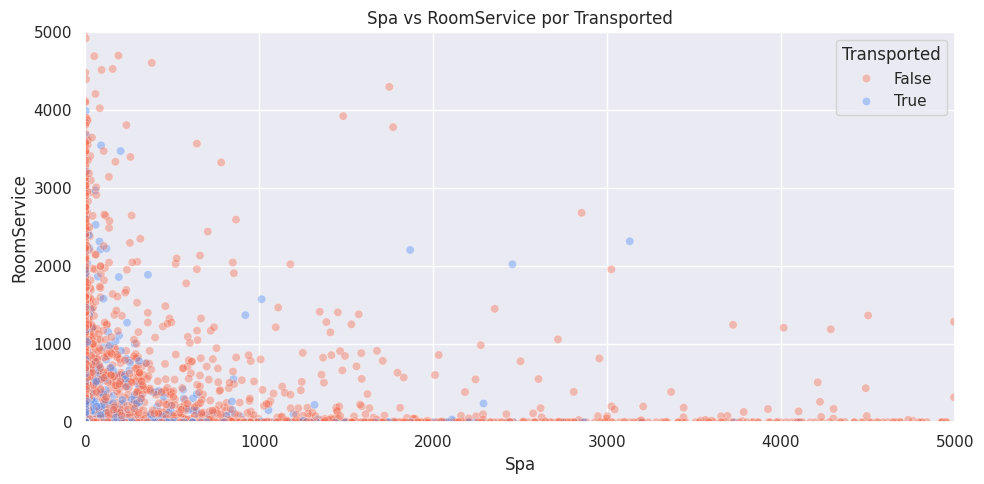

In [12]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df.dropna(subset=['Spa', 'RoomService', 'Transported']),
    x='Spa', y='RoomService',
    hue='Transported',
    alpha=0.4,
    palette={True: '#4e8df5', False: '#f56b4e'}
)
plt.title('Spa vs RoomService por Transported')
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.tight_layout()
plt.show()

### 2.6 Heatmap de Correlação

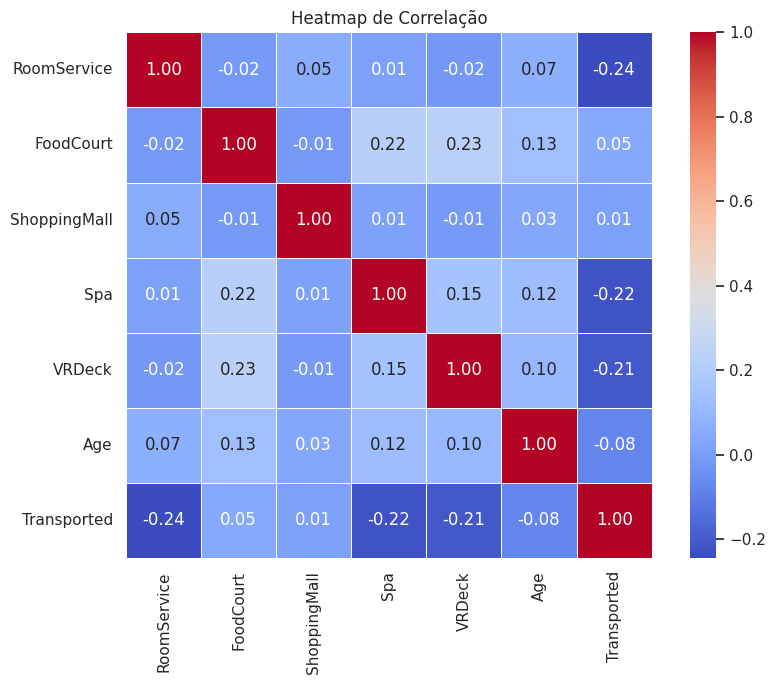

In [13]:
# Convertemos Transported para int temporariamente
df_corr = df[spend_cols + ['Age']].copy()
df_corr['Transported'] = df['Transported'].astype(float)

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_corr.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)
plt.title('Heatmap de Correlação')
plt.tight_layout()
plt.show()

### 2.7 Análise de Variáveis Categóricas

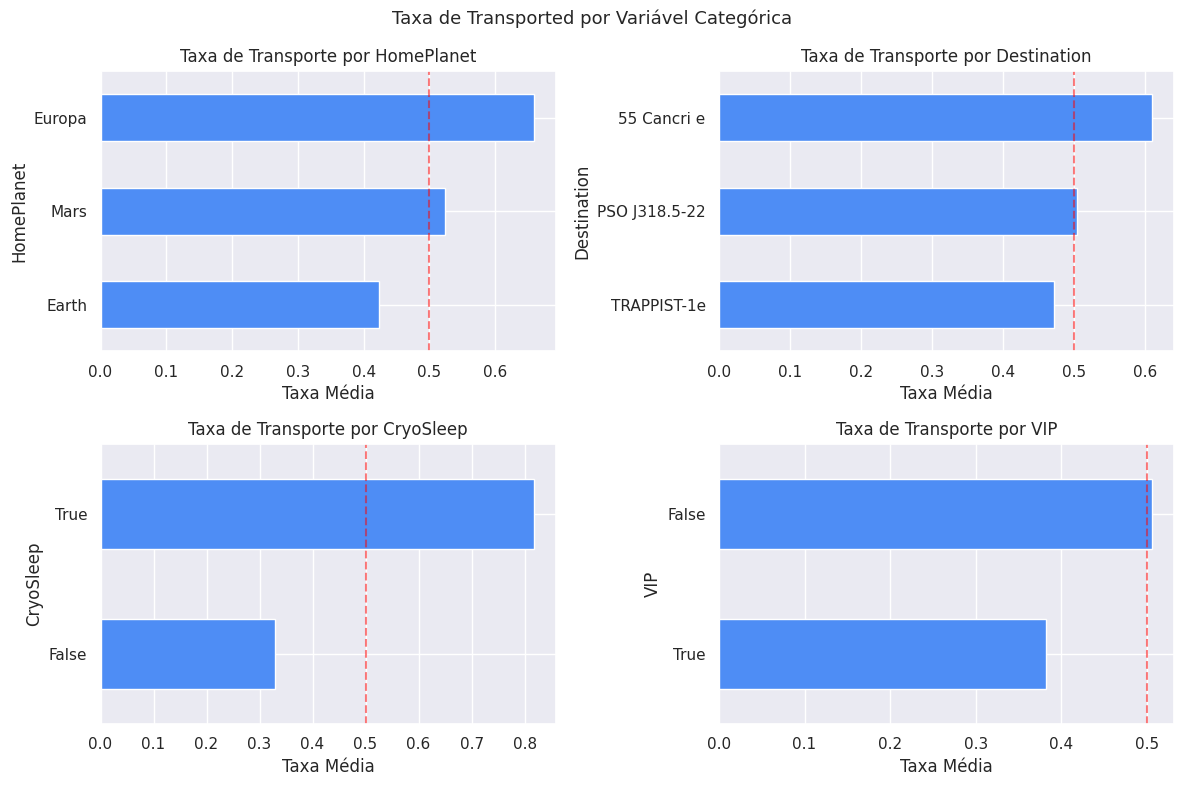

In [14]:
cat_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    data = df.dropna(subset=[col, 'Transported'])
    data[col] = data[col].astype(str)
    transported_rate = data.groupby(col)['Transported'].mean().sort_values()
    transported_rate.plot(kind='barh', ax=axes[i], color='#4e8df5')
    axes[i].set_title(f'Taxa de Transporte por {col}')
    axes[i].set_xlabel('Taxa Média')
    axes[i].axvline(0.5, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Taxa de Transported por Variável Categórica', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Engenharia de Atributos <a id='3'></a>

Criamos novos atributos derivados dos dados originais para enriquecer o modelo.

### Atributos criados:

| Atributo | Origem | Justificativa |
|---|---|---|
| `TotalSpend` | Soma dos 5 gastos a bordo | Passageiros que gastaram mais podem ter padrões diferentes de transporte |
| `Deck` | Extração da coluna `Cabin` (formato `deck/num/side`) | A posição na nave pode influenciar a probabilidade de transporte |
| `Side` | Extração da coluna `Cabin` | Lado da cabine (P/S) pode ter correlação com o transporte |
| `FaixaEtaria` | Agrupamento da coluna `Age` em faixas | Reduz o impacto de outliers e facilita a aprendizagem do modelo |

In [15]:
def feature_engineering(df):
    df = df.copy()

    # Atributo 1: Gasto total a bordo
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpend'] = df[spend_cols].fillna(0).sum(axis=1)

    # Atributo 2 e 3: Deck e Side extraídos da Cabin
    cabin_split = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = cabin_split[0]   # ex: 'B', 'F', 'G'...
    df['Side'] = cabin_split[2]   # 'P' ou 'S'

    # Atributo 4: Faixa etária
    df['FaixaEtaria'] = pd.cut(
        df['Age'],
        bins=[0, 12, 18, 35, 60, 200],
        labels=['Criança', 'Adolescente', 'Adulto Jovem', 'Adulto', 'Idoso']
    ).astype(str)

    return df

df = feature_engineering(df)

print('Novos atributos criados:')
print(df[['TotalSpend', 'Deck', 'Side', 'FaixaEtaria']].head(10))

Novos atributos criados:
   TotalSpend Deck Side   FaixaEtaria
0         0.0    B    P        Adulto
1       736.0    F    S  Adulto Jovem
2     10383.0    A    S        Adulto
3      5176.0    A    S  Adulto Jovem
4      1091.0    F    S   Adolescente
5       774.0    F    P        Adulto
6      1584.0    F    S  Adulto Jovem
7         0.0    G    S  Adulto Jovem
8      1018.0    F    S  Adulto Jovem
9         0.0    B    P   Adolescente


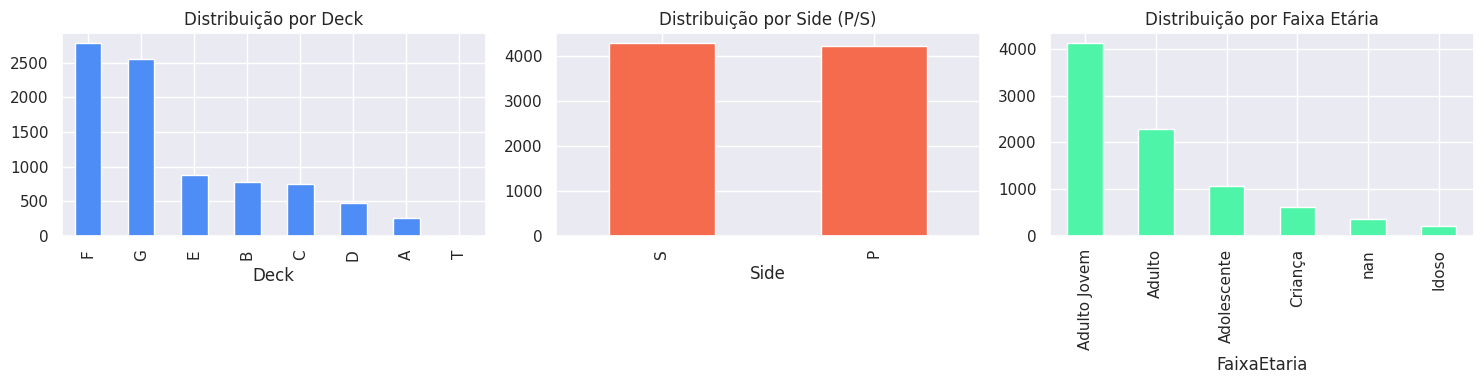

In [16]:
# Verificando distribuição dos novos atributos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Deck'].value_counts().plot(kind='bar', ax=axes[0], color='#4e8df5')
axes[0].set_title('Distribuição por Deck')

df['Side'].value_counts().plot(kind='bar', ax=axes[1], color='#f56b4e')
axes[1].set_title('Distribuição por Side (P/S)')

df['FaixaEtaria'].value_counts().plot(kind='bar', ax=axes[2], color='#4ef5a8')
axes[2].set_title('Distribuição por Faixa Etária')

plt.tight_layout()
plt.show()

---
## 4. Pré-processamento e Pipeline <a id='4'></a>

Utilizamos `Pipeline` e `ColumnTransformer` do Scikit-learn para organizar todas as transformações de forma segura e reproduzível.

In [17]:
# Seleção de features e target
FEATURES_NUM = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']
FEATURES_CAT = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP', 'Deck', 'Side', 'FaixaEtaria']

TARGET = 'Transported'

# Removendo colunas que não usaremos
df_model = df[FEATURES_NUM + FEATURES_CAT + [TARGET]].copy()

# Convertendo booleanos para string (serão tratados como categóricos)
df_model['CryoSleep'] = df_model['CryoSleep'].astype(str)
df_model['VIP'] = df_model['VIP'].astype(str)

# Separando features e target
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET].astype(int)

print(f'X shape: {X.shape}')
print(f'Distribuição do target:\n{y.value_counts()}')

X shape: (8693, 14)
Distribuição do target:
Transported
1    4378
0    4315
Name: count, dtype: int64


In [18]:
# Divisão treino/teste ANTES de qualquer transformação (evita data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

Treino: 6954 amostras
Teste:  1739 amostras


In [19]:
# Pipeline para variáveis numéricas
# Justificativa: imputação pela mediana é mais robusta a outliers do que a média
# StandardScaler normaliza os dados para algoritmos baseados em distância (KNN) e gradiente
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variáveis categóricas
# Justificativa: imputação pela moda mantém a distribuição original
# OneHotEncoder converte categorias para representação binária sem hierarquia implícita
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer: aplica cada pipeline às suas respectivas colunas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, FEATURES_NUM),
    ('cat', categorical_transformer, FEATURES_CAT)
])

print('✅ Preprocessor definido!')

✅ Preprocessor definido!


---
## 5. Data Leakage <a id='5'></a>

### O que é Data Leakage?

Data leakage ocorre quando **informações do conjunto de teste "vazam" para o treinamento** do modelo, causando uma estimativa artificialmente otimista de desempenho. O modelo aprende padrões que não estarão disponíveis em produção.

**Exemplos comuns de leakage:**
- Calcular a média para imputação **usando todo o dataset** (treino + teste) antes de dividir
- Fazer normalização **antes** do `train_test_split`
- Usar features derivadas do target

### Como evitamos neste projeto?

1. **Divisão treino/teste PRIMEIRO** — antes de qualquer transformação
2. **Pipeline do Scikit-learn** — o `fit` do pré-processador ocorre apenas nos dados de treino (`fit_transform`), e o teste recebe apenas o `transform`
3. **K-Fold dentro do Pipeline** — o `cross_val_score` e `GridSearchCV` respeitam as dobras e nunca deixam dados de validação "contaminarem" o fit

```
SEM pipeline (leakage):   fit_scaler(X_all) → split → treino/teste
COM pipeline (correto):   split → fit_scaler(X_train) → transform(X_test)
```

---
## 6. Modelagem <a id='6'></a>

In [20]:
# Pipeline completo: preprocessamento + modelo
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# Treinamento inicial
pipeline_lr.fit(X_train, y_train)
pipeline_knn.fit(X_train, y_train)

print(f'Acurácia Logistic Regression (treino): {pipeline_lr.score(X_train, y_train):.4f}')
print(f'Acurácia KNN             (treino): {pipeline_knn.score(X_train, y_train):.4f}')

Acurácia Logistic Regression (treino): 0.7936
Acurácia KNN             (treino): 0.8385


---
## 7. Validação: K-Fold e GridSearchCV <a id='7'></a>

### 7.1 K-Fold Cross Validation

O **K-Fold Cross Validation** divide o conjunto de treino em `k` partes (folds). O modelo é treinado em `k-1` folds e avaliado no fold restante, repetindo o processo `k` vezes. A média das acurácias fornece uma estimativa mais confiável do desempenho real do que uma única divisão treino/teste.

Usamos `k=5`, o que significa 5 rodadas com 80%/20% de treino/validação em cada.

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=kf, scoring='accuracy')
scores_knn = cross_val_score(pipeline_knn, X_train, y_train, cv=kf, scoring='accuracy')

print('=== K-Fold Cross Validation (k=5) ===')
print(f'Logistic Regression: {scores_lr}')
print(f'  Média: {scores_lr.mean():.4f} | Desvio: {scores_lr.std():.4f}')
print()
print(f'KNN:                 {scores_knn}')
print(f'  Média: {scores_knn.mean():.4f} | Desvio: {scores_knn.std():.4f}')

=== K-Fold Cross Validation (k=5) ===
Logistic Regression: [0.76923077 0.80301941 0.80661395 0.80086269 0.79496403]
  Média: 0.7949 | Desvio: 0.0134

KNN:                 [0.75413372 0.77282531 0.76347951 0.76923077 0.77985612]
  Média: 0.7679 | Desvio: 0.0087


### 7.2 GridSearchCV — Ajuste de Hiperparâmetros

O **GridSearchCV** testa todas as combinações de parâmetros definidas em um grid, usando Cross Validation para avaliar cada combinação. Escolhemos o modelo com melhor desempenho médio.

#### Parâmetros testados no KNN:
| Parâmetro | Valores | Influência |
|---|---|---|
| `n_neighbors` | 3, 5, 7, 11, 15 | Número de vizinhos considerados — valores baixos = mais sensível ao ruído; valores altos = fronteira mais suave |
| `weights` | uniform, distance | `distance` dá mais peso a vizinhos próximos |
| `metric` | euclidean, manhattan | Forma de calcular a distância entre pontos |

In [22]:
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 11, 15],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\n✅ Melhores parâmetros: {grid_search.best_params_}')
print(f'✅ Melhor acurácia (CV): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Melhores parâmetros: {'model__metric': 'euclidean', 'model__n_neighbors': 11, 'model__weights': 'uniform'}
✅ Melhor acurácia (CV): 0.7849


In [23]:
# Visualizando os resultados do GridSearch
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)
print('Top 10 combinações:')
print(results_df[['param_model__n_neighbors', 'param_model__weights',
                   'param_model__metric', 'mean_test_score', 'std_test_score']].head(10).to_string(index=False))

Top 10 combinações:
 param_model__n_neighbors param_model__weights param_model__metric  mean_test_score  std_test_score
                       11              uniform           euclidean         0.784873        0.004831
                       15              uniform           euclidean         0.784872        0.004254
                       11              uniform           manhattan         0.781710        0.005861
                       15              uniform           manhattan         0.781566        0.004879
                        7              uniform           manhattan         0.777540        0.010060
                        7              uniform           euclidean         0.775814        0.008885
                       15             distance           euclidean         0.774950        0.006142
                       11             distance           euclidean         0.772505        0.006016
                       15             distance           manhattan         0.772

---
## 8. Avaliação dos Resultados <a id='8'></a>

In [24]:
# Modelo final: melhor KNN encontrado pelo GridSearch
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'=== Avaliação no Conjunto de Teste ===')
print(f'Acurácia: {acc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Não Transportado', 'Transportado']))

=== Avaliação no Conjunto de Teste ===
Acurácia: 0.7809

Classification Report:
                  precision    recall  f1-score   support

Não Transportado       0.77      0.80      0.78       863
    Transportado       0.79      0.77      0.78       876

        accuracy                           0.78      1739
       macro avg       0.78      0.78      0.78      1739
    weighted avg       0.78      0.78      0.78      1739



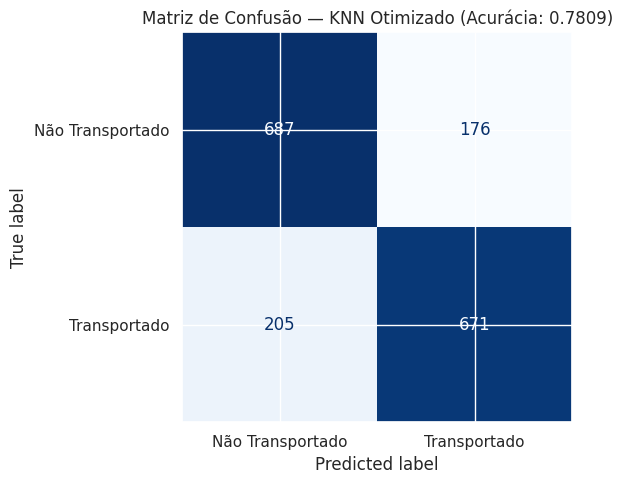

In [25]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Transportado', 'Transportado'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Matriz de Confusão — KNN Otimizado (Acurácia: {acc:.4f})')
plt.tight_layout()
plt.show()

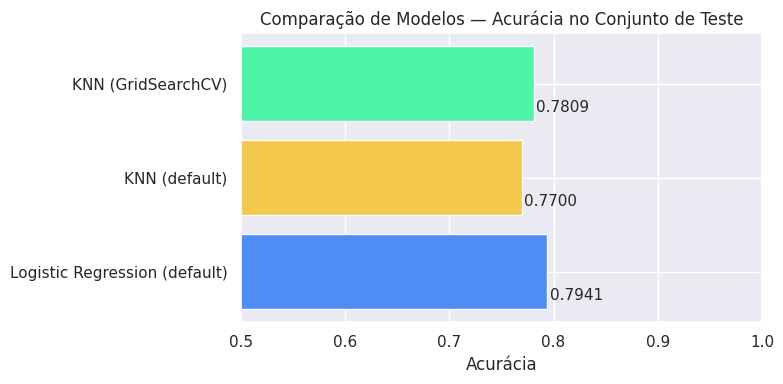

In [26]:
# Comparação final entre modelos
resultados = {
    'Logistic Regression (default)': pipeline_lr.score(X_test, y_test),
    'KNN (default)': pipeline_knn.score(X_test, y_test),
    'KNN (GridSearchCV)': acc
}

plt.figure(figsize=(8, 4))
bars = plt.barh(list(resultados.keys()), list(resultados.values()), color=['#4e8df5', '#f5c84e', '#4ef5a8'])
plt.xlabel('Acurácia')
plt.title('Comparação de Modelos — Acurácia no Conjunto de Teste')
plt.xlim(0.5, 1.0)
for bar, val in zip(bars, resultados.values()):
    plt.text(val + 0.002, bar.get_y() + 0.1, f'{val:.4f}', fontsize=11)
plt.tight_layout()
plt.show()

---
## 9. Discussão Final <a id='9'></a>

### Dificuldades encontradas

- Quase todas as colunas do dataset possuem valores ausentes, exigindo uma estratégia de imputação cuidadosa para cada tipo de variável.
- A coluna `Cabin` precisou ser parseada manualmente para extrair informações úteis (`Deck`, `Side`).
- Variáveis com forte assimetria (gastos a bordo) podem prejudicar algoritmos sensíveis à escala.

### Impacto do Pré-processamento

- A imputação pela mediana nas variáveis numéricas foi fundamental para não inflar os valores com outliers.
- O `StandardScaler` foi essencial para o KNN, que é sensível à escala das variáveis.
- A engenharia de atributos (`TotalSpend`, `Deck`, `Side`) agregou informações que o modelo não conseguiria extrair das colunas brutas.

### Limitações do Dataset

- Dataset sintético — pode não refletir complexidades do mundo real.
- Algumas colunas como `Name` e `PassengerId` foram descartadas por não agregarem poder preditivo direto.
- O desequilíbrio de classes é baixo (~50/50), o que favorece a acurácia como métrica principal.

### Possíveis Melhorias Futuras

- Explorar o `PassengerId` para extrair o grupo familiar (os IDs seguem o padrão `XXXX_NN`)
- Testar modelos mais poderosos como `RandomForestClassifier` ou `GradientBoostingClassifier`
- Aplicar `SelectKBest` para seleção de features dentro do pipeline
- Usar `StratifiedKFold` para garantir proporção do target em cada fold